In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)


Python executable: c:\Users\User\miniconda3\envs\nvidia_project\python.exe
Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]


In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

CUDA available: True
GPU name: NVIDIA GeForce RTX 2080 Super with Max-Q Design


In [3]:
# 1️⃣ INSTALL DEPENDENCIES
print("⏳ Installing dependencies...")
# %pip install -qU langchain-groq langchain-huggingface langchain-chroma langgraph langchain-community sentence-transformers unstructured chromadb gradio

import chromadb
print("✅ Dependencies installed.")

⏳ Installing dependencies...
✅ Dependencies installed.


In [4]:
# 2️⃣ CONFIGURATION

# Define where our data lives
SOURCE_DATA_DIR = "C:/Users/User/NTU_DSAI/Module-5/Jony_Nvidia_1/Nvidia_Annual_Reports_2014-2025"
DRIVE_DB_PATH = "C:/Users/User/NTU_DSAI/Module-5/Jony_Nvidia_1/chroma_db_v2"
EMBEDDING_MODEL = "all-mpnet-base-v2"

from dotenv import load_dotenv
load_dotenv()

import os
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("Set the OPENAI_API_KEY environment variable before running this notebook.")

from langchain_openai import ChatOpenAI # type: ignore

# Recommended model for this project (tool calling + reasoning)
llm = ChatOpenAI(
    model="gpt-5.4",           # Best balance for agents (or "gpt-5.4-mini" for cheaper/faster)
    temperature=0.3,
    max_tokens=1024, # type: ignore
)

print("✅ Switched to OpenAI GPT-5.4 (excellent tool calling)")
print("✅ Environment Ready.")

c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Switched to OpenAI GPT-5.4 (excellent tool calling)
✅ Environment Ready.


In [5]:
# ========================
# ULTIMATE ONE-CELL FIX - Large Chunks + Hybrid Extraction
# ========================

from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from chromadb.config import Settings
import os
import re
import torch

# Config
SOURCE_DATA_DIR = r"C:\Users\User\NTU_DSAI\Module-5\Jony_Nvidia_1\Nvidia_Annual_Reports_2014-2025"
DRIVE_DB_PATH = r"C:\Users\User\NTU_DSAI\Module-5\Jony_Nvidia_1\chroma_db_v2"
EMBEDDING_MODEL = "all-mpnet-base-v2"

device = "cuda" if torch.cuda.is_available() else "cpu"
embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL, model_kwargs={"device": device})

persistent_client = chromadb.PersistentClient(path=DRIVE_DB_PATH, settings=Settings(allow_reset=True))

def build_or_load():
    collection_name = "nvidia_annual_reports_2014_2025"
    existing = [c.name for c in persistent_client.list_collections()]
    if collection_name in existing:
        print("✅ Loading existing collection...")
        return Chroma(client=persistent_client, collection_name=collection_name, embedding_function=embeddings)
    
    print("Building with large chunks for tables...")
    loader = DirectoryLoader(SOURCE_DATA_DIR, glob="**/*.pdf", loader_cls=PyPDFLoader, show_progress=True) # type: ignore
    docs = loader.load()
    
    for doc in docs:
        match = re.search(r'(\d{4})', doc.metadata.get('source', ''))
        if match:
            doc.metadata['year'] = int(match.group(1))
        doc.metadata['source_type'] = 'annual_report'
    
    splitter = RecursiveCharacterTextSplitter(chunk_size=2500, chunk_overlap=600)
    split_docs = splitter.split_documents(docs)
    
    vectorstore = Chroma.from_documents(documents=split_docs, embedding=embeddings, 
                                       client=persistent_client, collection_name=collection_name)
    print(f"🎉 Built with {vectorstore._collection.count()} chunks")
    return vectorstore

vectorstore = build_or_load()

# ========================
# STRONG TEST WITH HYBRID EXTRACTION
# ========================
retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"k": 10, "score_threshold": 0.15, "filter": {"year": 2016}}
)

docs = retriever.invoke("gross profit fiscal year 2016 Consolidated Statements of Income table amount in millions")
context = "\n\n".join([doc.page_content for doc in docs])

print("Raw Context Preview:")
print(context[:1500] + "...")

# LLM Extraction
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_template("""
You are an expert financial analyst. Extract the exact Gross Profit number for fiscal year 2016 from the context.
Look carefully for any table row containing "Gross profit" or "gross profit".
Answer in this format only: Gross profit = $X,XXX million

Context:
{context}
""")

result = (prompt | llm).invoke({"context": context})
print("\n" + "="*80)
print("FINAL EXTRACTION:")
print(result.content)
print("="*80)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6418.14it/s]


✅ Loading existing collection...
Raw Context Preview:
Consolidated Statements of Income for the years ended January 31, 2016, January 25, 2015, and January 26, 2014.........................................................................................................................................................

Consolidated Statements of Cash Flows for the years ended January 31, 2016, January 25, 2015, and January 26, 2014 ...........................................................................................................................................

Consolidated Statements of Comprehensive Income for the years ended January 31, 2016, January 25, 2015, and January 26, 2014 ..........................................................................................................................

Consolidated Statement of Operations Data: Revenue....................................................... $ Income from operations............................... $ Net income..

In [6]:
# ========================
# FIXED RETRIEVAL CHAIN (Correct Chroma Filter Syntax)
# ========================

def run_retrieval_chain(query: str):
    """Modern, reliable retrieval with correct Chroma filters"""
    try:
        # Detect year
        year_match = re.search(r'20(\d{2})', query)
        year = int("20" + year_match.group(1)) if year_match else None
        
        # Correct Chroma filter syntax
        if year:
            filter_dict = {"$and": [
                {"source_type": "annual_report"},
                {"year": year}
            ]}
        else:
            filter_dict = {"source_type": "annual_report"}
        
        retriever = vectorstore.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs={
                "k": 10,
                "score_threshold": 0.18,
                "filter": filter_dict
            }
        )
        
        docs = retriever.invoke(query)
        context = "\n\n".join([doc.page_content for doc in docs])
        
        # LLM Extraction
        prompt = ChatPromptTemplate.from_template("""
        You are NVIDIA's expert financial analyst.
        Use the context to answer accurately with exact numbers when available.

        Context:
        {context}

        Question: {query}

        Answer:
        """)
        
        chain = prompt | llm
        result = chain.invoke({"context": context, "query": query})
        
        return {"answer": result.content}
        
    except Exception as e:
        return {"answer": f"Error: {str(e)}"}

# ========================
# TEST
# ========================
print("🧠 Testing 2017 Financial Status...\n")
response = run_retrieval_chain("What is Nvidia's overall financial status and revenue for financial year 2017?")
print(f"✅ Final Answer:\n{response['answer']}")

print("\n" + "="*80)
response2 = run_retrieval_chain("What was Nvidia's gross profit in 2016?")
print(f"Gross Profit 2016 Test:\n{response2['answer']}")

🧠 Testing 2017 Financial Status...

✅ Final Answer:
For fiscal year 2017, NVIDIA’s overall financial status was strong and improved significantly versus the prior year.

- Revenue: $6.91 billion
- Net income: $1.67 billion
- Total assets: $9.84 billion
- Cash, cash equivalents, and marketable securities: about $7.24 billion
- Shareholders’ equity: about $7.02 billion

Overall, fiscal 2017 was a very strong year for NVIDIA, marked by high revenue growth, solid profitability, and a strong balance sheet with substantial cash holdings.

Gross Profit 2016 Test:
NVIDIA's gross profit in fiscal year 2016 was approximately **$2.81 billion**.

Calculation:
- **Revenue:** $5.01 billion
- **Gross margin:** 56.1%

**Gross profit = $5.01 billion × 56.1% = $2.81 billion**


In [7]:
# ========================
# DOWNLOAD NVIDIA HISTORICAL DATA (2014–2025)
# ========================

import yfinance as yf
import pandas as pd
from datetime import datetime

# Define ticker and date range
ticker = "NVDA"
start_date = "2014-01-01"
end_date = None   # or leave as None for latest data

print(f"📥 Downloading {ticker} data from {start_date} to {end_date}...")

# Download data
df = yf.download(
    tickers=ticker,
    start=start_date,
    end=end_date,
    interval="1d",           # daily
    auto_adjust=True,        # adjust for splits & dividends
    progress=True
)

# Basic cleaning & feature engineering (great for your ML model)
df = df.reset_index() # type: ignore
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
df['Date'] = pd.to_datetime(df['Date'])

# Add useful columns for time-series / Prophet / LSTM
# df['Year'] = df['Date'].dt.year
# df['Month'] = df['Date'].dt.month
# df['DayOfWeek'] = df['Date'].dt.dayofweek
# df['Return'] = df['Close'].pct_change()
# df['MA7'] = df['Close'].rolling(window=7).mean()      # 7-day moving average
# df['MA30'] = df['Close'].rolling(window=30).mean()

print(f"✅ Download complete! Shape: {df.shape}")
print(df.head())
print(df.tail())

# Save to CSV (perfect for your notebook & app.py)
output_file = f"nvda_{start_date[:4]}_to_{datetime.now().strftime('%Y')}.csv"
df.to_csv(output_file, index=False)
print(f"💾 Saved to: {output_file}")

📥 Downloading NVDA data from 2014-01-01 to None...


[*********************100%***********************]  1 of 1 completed

✅ Download complete! Shape: (3096, 6)
Price        Date      Open      High       Low     Close     Volume
Ticker                 NVDA      NVDA      NVDA      NVDA       NVDA
0      2014-01-02  0.375258  0.376672  0.370544  0.373844  260092000
1      2014-01-03  0.374551  0.375258  0.368187  0.369365  259332000
2      2014-01-06  0.373137  0.377144  0.369601  0.374315  409492000
3      2014-01-07  0.378087  0.381858  0.375494  0.380444  333288000
4      2014-01-08  0.381858  0.387515  0.380444  0.385629  308192000
Price        Date        Open        High         Low       Close     Volume
Ticker                   NVDA        NVDA        NVDA        NVDA       NVDA
3091   2026-04-20  199.979996  202.169998  197.839996  202.059998  119381400
3092   2026-04-21  202.130005  202.750000  199.000000  199.880005  107945300
3093   2026-04-22  200.990005  202.500000  199.000000  202.500000  107501000
3094   2026-04-23  202.460007  203.830002  197.220001  199.639999  113561800
3095   2026-04-24

In [ ]:
# ========================
# FIXED ML TOOL: Prophet 7-Day Trend Prediction (Capstone Component 1)
# ========================

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Load and CLEAN the CSV (removes the bad NVDA header row)
df = pd.read_csv(
    "C:/Users/User/NTU_DSAI/Module-5/Jony_Nvidia_1/nvda_2014_to_2026.csv",
    skiprows=[1],
)
df = df.dropna(subset=["Date"]).copy()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for col in ["Close", "High", "Low", "Open", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna().sort_values("Date").reset_index(drop=True)

print(df.head())
print(f"Cleaned dataset: {len(df)} trading days | Latest close: ${df['Close'].iloc[-1]:.2f}")

def predict_7_days_prophet() -> pd.DataFrame:
    """Return the next 7 business-day Nvidia close forecasts."""
    try:
        df_prophet = df[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"}).copy()
        df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], errors="coerce")
        df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")
        df_prophet = df_prophet.dropna().sort_values("ds").reset_index(drop=True)

        prophet_model = Prophet(
            daily_seasonality=True, # type: ignore
            weekly_seasonality=True, # type: ignore
            yearly_seasonality=True, # type: ignore
            changepoint_prior_scale=0.8,
            interval_width=0.95,
        )
        prophet_model.fit(df_prophet)

        future = prophet_model.make_future_dataframe(periods=7, freq="B")
        forecast = prophet_model.predict(future)

        pred = forecast.tail(7)[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()
        pred = pred.rename(
            columns={
                "ds": "Date",
                "yhat": "Predicted_Close",
                "yhat_lower": "Lower_Bound",
                "yhat_upper": "Upper_Bound",
            }
        )
        pred["Predicted_Close"] = pred["Predicted_Close"].round(2)
        pred["Lower_Bound"] = pred["Lower_Bound"].round(2)
        pred["Upper_Bound"] = pred["Upper_Bound"].round(2)
        pred["Date"] = pred["Date"].dt.strftime("%Y-%m-%d")
        return pred[["Date", "Predicted_Close", "Lower_Bound", "Upper_Bound"]]
    except Exception as e:
        return pd.DataFrame({"Error": [f"Prophet unavailable: {str(e)}"]})

def plot_prophet_forecast() -> None:
    """Train Prophet once for charts and display the latest 7-day outlook."""
    df_prophet = df[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"}).copy()
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], errors="coerce")
    df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")
    df_prophet = df_prophet.dropna().sort_values("ds").reset_index(drop=True)

    prophet_model = Prophet(
        daily_seasonality=True, # type: ignore
        weekly_seasonality=True, # type: ignore
        yearly_seasonality=True, # type: ignore
        changepoint_prior_scale=0.8,
        interval_width=0.95,
    )
    prophet_model.fit(df_prophet)

    future = prophet_model.make_future_dataframe(periods=7, freq="B")
    forecast = prophet_model.predict(future)

    print("\nNVIDIA 7-DAY PRICE TREND PREDICTION")
    print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(7).to_string(index=False))

    fig1 = prophet_model.plot(forecast)
    plt.title("NVIDIA Stock Price Forecast (Next 7 Business Days) - Capstone ML Tool")
    plt.xlabel("Date")
    plt.ylabel("Close Price ($)")
    plt.show()

    fig2 = prophet_model.plot_components(forecast)
    plt.show()

    forecast.tail(7).to_csv("nvidia_7day_forecast.csv", index=False)
    print("Forecast saved as nvidia_7day_forecast.csv")

print(predict_7_days_prophet().to_markdown(index=False))

Importing plotly failed. Interactive plots will not work.


        Date      Open      High       Low     Close     Volume
0 2014-01-02  0.375258  0.376672  0.370544  0.373844  260092000
1 2014-01-03  0.374551  0.375258  0.368187  0.369365  259332000
2 2014-01-06  0.373137  0.377144  0.369601  0.374315  409492000
3 2014-01-07  0.378087  0.381858  0.375494  0.380444  333288000
4 2014-01-08  0.381858  0.387515  0.380444  0.385629  308192000
Cleaned dataset: 3096 trading days | Latest close: $208.27


13:51:41 - cmdstanpy - INFO - Chain [1] start processing
13:51:43 - cmdstanpy - INFO - Chain [1] done processing


| Date       |   Predicted_Close |   Lower_Bound |   Upper_Bound |
|:-----------|------------------:|--------------:|--------------:|
| 2026-04-27 |            199.36 |        185.4  |        213.43 |
| 2026-04-28 |            199.55 |        186.71 |        213.47 |
| 2026-04-29 |            199.82 |        185.39 |        213.57 |
| 2026-04-30 |            200.08 |        186.87 |        213.63 |
| 2026-05-01 |            200.33 |        187.12 |        213.78 |
| 2026-05-04 |            201.11 |        186.52 |        214.65 |
| 2026-05-05 |            201.3  |        187.14 |        215.24 |


✅ Dataset ready: 3096 days | Latest: $208.27


13:51:44 - cmdstanpy - INFO - Chain [1] start processing
13:51:45 - cmdstanpy - INFO - Chain [1] done processing



=== 90-DAY HOLD-OUT BACKTEST (Strict Future) ===
MAE   : $10.24
RMSE  : $13.44
MAPE  : 5.71%
Latest actual: $208.27 | Predicted: $203.36


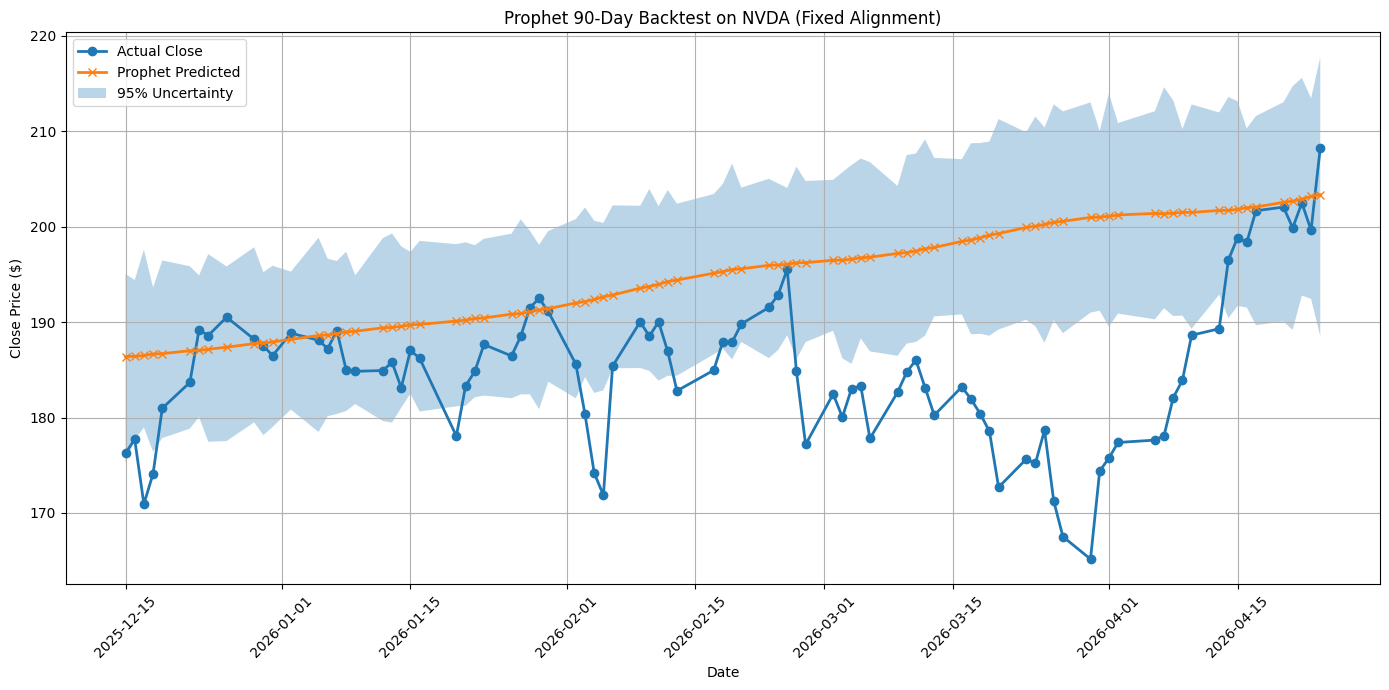


Running Cross-Validation (this may take 30-60s)...

Cross-Validation Performance Summary:
  horizon       mae       rmse      mape
0  4 days  5.531408   9.687415  0.157107
1  5 days  5.480429   9.329691  0.155549
2  6 days  5.517064   9.230556  0.154225
3  7 days  5.759947   9.794648  0.164680
4  8 days  5.922438  10.275410  0.168351
5  9 days  6.120107  10.798786  0.175799
6 10 days  5.667872  10.197558  0.174035
7 11 days  5.290257   9.354095  0.165395
8 12 days  5.426475   9.351503  0.163593
9 13 days  6.258960  10.546633  0.173511


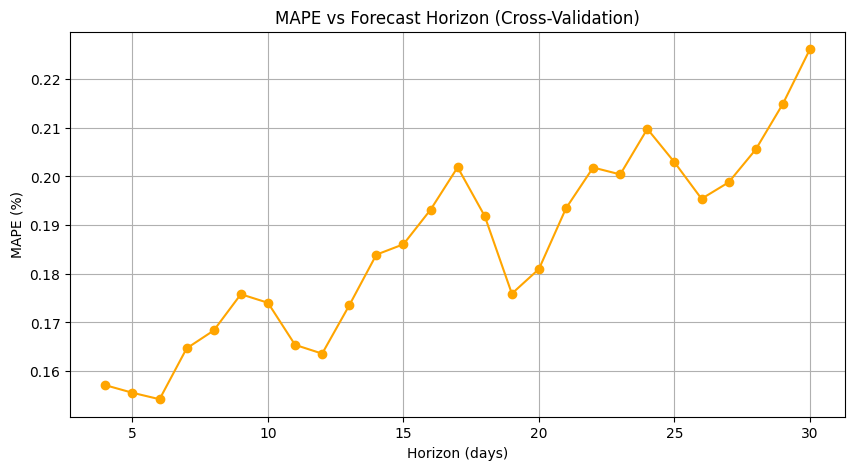

✅ Backtest saved as prophet_90day_backtest.csv


In [9]:
# ========================
# FIXED + ROBUST PROPHET EVALUATION (Capstone ML Component 1)
# ========================
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use the cleaned df from previous cell (already loaded globally)
df_prophet = df[['Date', 'Close']].rename(columns={'Date': 'ds', 'Close': 'y'}).copy()
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'])
df_prophet = df_prophet.dropna().sort_values('ds').reset_index(drop=True)

print(f"✅ Dataset ready: {len(df_prophet)} days | Latest: ${df_prophet['y'].iloc[-1]:.2f}")

# =========================
# 1. Improved Train-Test Split (strict future hold-out)
# =========================
test_size = 90
train = df_prophet.iloc[:-test_size].copy()
test = df_prophet.iloc[-test_size:].copy()

model = Prophet(
    daily_seasonality=True, # type: ignore
    weekly_seasonality=True, # type: ignore
    yearly_seasonality=True, # type: ignore
    changepoint_prior_scale=0.8,      # Higher flexibility for NVDA volatility
    seasonality_prior_scale=10.0,
    uncertainty_samples=100
)
model.fit(train)

# Predict exactly on test dates (no extra future days)
future = pd.DataFrame({'ds': test['ds']})
forecast = model.predict(future)

# Merge for evaluation
eval_df = test.merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left')

mae = mean_absolute_error(eval_df['y'], eval_df['yhat'])
rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))
mape = np.mean(np.abs((eval_df['y'] - eval_df['yhat']) / eval_df['y'])) * 100

print("\n=== 90-DAY HOLD-OUT BACKTEST (Strict Future) ===")
print(f"MAE   : ${mae:.2f}")
print(f"RMSE  : ${rmse:.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"Latest actual: ${eval_df['y'].iloc[-1]:.2f} | Predicted: ${eval_df['yhat'].iloc[-1]:.2f}")

# Plot
plt.figure(figsize=(14, 7))
plt.plot(eval_df['ds'], eval_df['y'], label='Actual Close', marker='o', linewidth=2)
plt.plot(eval_df['ds'], eval_df['yhat'], label='Prophet Predicted', marker='x', linewidth=2)
plt.fill_between(eval_df['ds'], eval_df['yhat_lower'], eval_df['yhat_upper'], alpha=0.3, label='95% Uncertainty')
plt.title('Prophet 90-Day Backtest on NVDA (Fixed Alignment)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 2. Rolling Cross-Validation (Robust)
# =========================
print("\nRunning Cross-Validation (this may take 30-60s)...")
df_cv = cross_validation(
    model,
    initial='730 days',   # 2 years training minimum
    period='90 days',
    horizon='30 days',
    parallel='processes'  # Faster on your RTX 2080
)

perf = performance_metrics(df_cv)
print("\nCross-Validation Performance Summary:")
print(perf[['horizon', 'mae', 'rmse', 'mape']].head(10)) # type: ignore

# Plot MAPE trend
perf['horizon_days'] = perf['horizon'].dt.days # type: ignore
plt.figure(figsize=(10, 5))
plt.plot(perf['horizon_days'], perf['mape'], marker='o', color='orange') # type: ignore
plt.title('MAPE vs Forecast Horizon (Cross-Validation)')
plt.xlabel('Horizon (days)')
plt.ylabel('MAPE (%)')
plt.grid(True)
plt.show()

# Save for your Trader agent / Telegram bot
eval_df.to_csv("prophet_90day_backtest.csv", index=False)
print("✅ Backtest saved as prophet_90day_backtest.csv")

In [10]:
import pandas as pd
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate

# 1. Initialize the DuckDuckGo Tool
ddg_search_tool = DuckDuckGoSearchRun(
    name="duckduckgo_search",
    description="Search the web for the latest news, current events, or live stock market updates regarding Nvidia."
)

# 2. Prophet-based stock forecast tool
@tool
def predict_nvidia_stock() -> dict:
    """Forecast the next 7 business-day Nvidia closing prices using Prophet."""
    try:
        pred_df = predict_7_days_prophet() # type: ignore
        if "Error" in pred_df.columns:
            return {"error": pred_df.iloc[0, 0]}

        next_day_prediction = float(pred_df.iloc[0]["Predicted_Close"])
        return {
            "prediction": next_day_prediction,
            "forecast_table": pred_df.to_dict(orient="records")
        }
    except Exception as e:
        return {"error": str(e)}

# 3. Define the RAG Tool
@tool
def search_nvidia_annual_report(query: str) -> str:
    """
    Searches Nvidia annual reports (2014-2025) for financial data,
    revenue, gross profit, risks, strategy, etc.
    """
    try:
        # Auto-detect year for better filtering
        year_match = re.search(r'20(\d{2})', query)
        year = int("20" + year_match.group(1)) if year_match else None

        filter_dict = {"source_type": "annual_report"}
        if year:
            filter_dict = {"$and": [{"source_type": "annual_report"}, {"year": year}]}

        retriever = vectorstore.as_retriever(
            search_type="similarity_score_threshold",
            search_kwargs={
                "k": 10,
                "score_threshold": 0.18,
                "filter": filter_dict
            }
        )

        docs = retriever.invoke(query)
        context = "\n\n".join([doc.page_content for doc in docs])

        prompt = ChatPromptTemplate.from_template("""
        You are NVIDIA's expert financial analyst.
        Answer the question accurately using the provided context.
        Include exact numbers and years when available.

        Question: {query}
        Context: {context}

        Clear, well-formatted Answer:
        """)

        result = (prompt | llm).invoke({"query": query, "context": context})
        return result.content.strip() # type: ignore

    except Exception as e:
        return f"Could not retrieve exact data. Error: {str(e)}"

# 4. Update your master list of tools to include all three
agent_tools = [
    ddg_search_tool,
    predict_nvidia_stock,
    search_nvidia_annual_report
]

print(f"Toolkit updated! Active tools: {[t.name for t in agent_tools]}")

# 5. Re-bind the updated toolkit to your LLM
llm_with_tools = llm.bind_tools(agent_tools)

# --- TEST THE BINDING ---
test_query = "What did Nvidia's 2025 annual report say about their gross profit?"
test_response = llm_with_tools.invoke(test_query)

print("\nTool Calls Triggered by LLM:")
print(test_response.tool_calls)

Toolkit updated! Active tools: ['duckduckgo_search', 'predict_nvidia_stock', 'search_nvidia_annual_report']

Tool Calls Triggered by LLM:
[{'name': 'search_nvidia_annual_report', 'args': {'query': '2025 annual report gross profit'}, 'id': 'call_t823BVnExTFck9WGXOIqlUCe', 'type': 'tool_call'}]


In [11]:
# ========================
# IMPROVED ROUTER NODE (Strong & Reliable)
# ========================

from langchain_core.messages import SystemMessage, HumanMessage

def router_node(state):
    query = state["query"]
    query_lower = query.lower()
    
    router_prompt = """
    You are a precise router for the NVIDIA AI Assistant.
    Classify the user's query into EXACTLY ONE of these categories.
    Output ONLY the exact category name, nothing else.

    Categories:
    - "ML_agent"               → stock price prediction, forecast, tomorrow's price, next day price, ML model
    - "results_strategy_agent" → revenue, financial results, gross profit, annual report, risks, strategy, Blackwell, future plans, business performance, product roadmap
    - "outlook_agent"          → latest news, market outlook, recent events, analyst opinions, current sentiment
    - "general_agent"          → general overview, products, company history, casual questions, what does Nvidia sell

    Query: {query}

    Your answer (only one exact category name):
    """

    try:
        response = llm.invoke([
            SystemMessage(content=router_prompt.format(query=query)),
            HumanMessage(content=query)
        ])
        
        decision = response.content.strip().strip('"\'').lower() # type: ignore

        # === STRONG KEYWORD OVERRIDE (most reliable) ===
        if any(kw in query_lower for kw in ["revenue", "profit", "financial", "gross", "earnings", "balance sheet", "report", "risk"]):
            decision = "results_strategy_agent"
        elif any(kw in query_lower for kw in ["blackwell", "strategy", "future plans", "roadmap"]):
            decision = "results_strategy_agent"
        elif any(kw in query_lower for kw in ["predict", "stock price", "tomorrow", "forecast", "next day", "ml model"]):
            decision = "ML_agent"
        elif any(kw in query_lower for kw in ["news", "latest", "outlook", "market", "analyst", "recent"]):
            decision = "outlook_agent"
        elif any(kw in query_lower for kw in ["product", "sell", "overview", "history", "what is nvidia"]):
            decision = "general_agent"

    except Exception:
        # Fallback to smart keyword routing if LLM fails
        if any(kw in query_lower for kw in ["revenue", "profit", "financial", "gross", "report", "risk", "blackwell", "strategy"]):
            decision = "results_strategy_agent"
        elif any(kw in query_lower for kw in ["predict", "stock", "price", "forecast"]):
            decision = "ML_agent"
        elif any(kw in query_lower for kw in ["news", "latest", "outlook", "market"]):
            decision = "outlook_agent"
        else:
            decision = "general_agent"

    return {
        "next_node": decision,
        "debug_log": f"🚦 Router Decision: {decision}"
    }

In [12]:
# 🛠️ TOOL EXECUTION NODE
from langgraph.prebuilt import ToolNode

# This single node handles executing ANY tool called by your agents
tool_node = ToolNode(agent_tools)

print("✅ Tool Node successfully defined!")

✅ Tool Node successfully defined!


In [13]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

# ========================
# FIXED AGENT NODES (Robust Output Handling)
# ========================

# ========================
# UPDATED AGENT NODES - PROPER TOOL HANDLING
# ========================

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage

# ------------------------------------------------------------------
# IMPROVED ML AGENT (Prophet forecast)
# ------------------------------------------------------------------
def ml_agent(state):
    query = state["query"].lower()
    debug = state.get("debug_log", "") + "\nML Agent (Stock Prediction) activated."

    if any(word in query for word in ["predict", "next day", "tomorrow", "stock price", "closing price", "forecast", "ml model"]):
        try:
            pred_df = predict_7_days_prophet() # type: ignore
            if "Error" in pred_df.columns:
                raise ValueError(pred_df.iloc[0, 0])

            next_price = float(pred_df.iloc[0]["Predicted_Close"])
            table_md = pred_df.to_markdown(index=False)

            response = f"""**NVIDIA 7-Business-Day Stock Forecast (Prophet ML)**

**Next Trading Day Close:** **${next_price:,.2f}**

**7-Day Outlook:**
{table_md}

*Forecast generated from cleaned NVDA historical close data using Prophet.*
"""
            debug += f"\nPrediction successful -> ${next_price:,.2f}"
        except Exception as e:
            response = f"ML Prediction unavailable: {str(e)}"
            debug += f"\nError: {str(e)}"
    else:
        response = "I can forecast Nvidia's next 7 business-day closing prices using Prophet. Ask me for a stock forecast."

    return {**state, "response": response, "debug_log": debug}

# ------------------------------------------------------------------
def results_strategy_agent(state):
    query = state["query"]

    sys_prompt = SystemMessage(content="""
    You are NVIDIA's expert financial and strategy analyst.
    For ANY question involving revenue, profit, financial results, risks, strategy, Blackwell,
    or annual reports - you MUST use the 'search_nvidia_annual_report' tool first.
    Do not answer from memory. Always call the tool.
    """)

    messages = [
        sys_prompt,
        HumanMessage(content=f"Use the tool to answer this accurately: {query}")
    ]

    response = llm_with_tools.invoke(messages)

    if response.tool_calls:
        tool_call = response.tool_calls[0]
        if tool_call["name"] == "search_nvidia_annual_report":
            tool_result = search_nvidia_annual_report.invoke(tool_call["args"])

            final_response = llm.invoke([
                sys_prompt,
                HumanMessage(content=query),
                AIMessage(content=response.content, tool_calls=[tool_call]),
                ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]),
                HumanMessage(content="Now provide a clear, professional, well-formatted final answer.")
            ])

            return {
                "response": final_response.content,
                "debug_log": "Results & Strategy Agent (Tool used successfully)",
                "messages": [final_response]
            }

    return {
        "response": "I couldn't retrieve the latest report data. Please try rephrasing or ask about a specific year.",
        "debug_log": "Results Agent fallback",
        "messages": [response]
    }

# ------------------------------------------------------------------
def outlook_agent(state):
    query = state["query"]
    sys_prompt = SystemMessage(content="""
    You are NVIDIA's Market Intelligence Agent.
    Use the 'duckduckgo_search' tool to fetch the latest news and market outlook.
    After getting the search results, summarize them clearly and concisely.
    """)

    response = llm_with_tools.invoke([sys_prompt, HumanMessage(content=query)])

    if isinstance(response, AIMessage) and response.tool_calls:
        tool_call = response.tool_calls[0]

        if tool_call["name"] == "duckduckgo_search":
            try:
                tool_result = ddg_search_tool.invoke(tool_call["args"])
                final_messages = [
                    sys_prompt,
                    HumanMessage(content=query),
                    AIMessage(content=f"Search results: {tool_result}"),
                    HumanMessage(content="Summarize the latest news and market outlook for Nvidia clearly and professionally.")
                ]
                final_response = llm.invoke(final_messages)
                return {
                    "messages": [final_response],
                    "debug_log": "Outlook Agent -> Search tool executed successfully"
                }
            except Exception as e:
                return {
                    "messages": [AIMessage(content=f"Search failed: {str(e)}")],
                    "debug_log": f"Outlook Agent -> Error: {e}"
                }

    return {
        "messages": [response],
        "debug_log": "Outlook Agent (no tool call)"
    }

# ------------------------------------------------------------------
def general_agent(state):
    query = state["query"]
    sys_prompt = SystemMessage(content="""
    You are a helpful NVIDIA assistant.
    Answer general questions conversationally.
    Use tools only when necessary (especially for financial or news-related queries).
    """)

    if any(kw in query.lower() for kw in ["revenue", "profit", "financial", "report", "risk", "blackwell"]):
        try:
            tool_result = search_nvidia_annual_report.invoke({"query": query}) # type: ignore
            return {
                "messages": [AIMessage(content=tool_result)],
                "debug_log": "General Agent -> RAG fallback used"
            }
        except:
            pass

    response = llm_with_tools.invoke([sys_prompt, HumanMessage(content=query)])

    return {
        "messages": [response],
        "debug_log": "General Agent activated."
    }

In [14]:
# ========================
# 9️⃣ BUILD LANGGRAPH WORKFLOW
# ========================

from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage

# Define the state
class AgentState(TypedDict):
    query: str
    messages: list
    response: str
    next_node: str
    debug_log: str

# Helper to extract final text from agent output
def extract_final_text(agent_result) -> str:
    try:
        msgs = agent_result.get("messages", [])
        if msgs:
            last = msgs[-1]
            return getattr(last, "content", str(last))
    except Exception:
        pass
    return str(agent_result)

# ========================
# AGENT NODES
# ========================

def ml_agent_node(state: AgentState):
    result = ml_agent(state)
    return {
        "response": result.get("response", "Sorry, I couldn't generate a prediction."),
        "debug_log": state.get("debug_log", "") + "\n🤖 ML Agent (Stock Prediction) activated.",
        "messages": result.get("messages", [])
    }

def results_strategy_agent_node(state: AgentState):
    result = results_strategy_agent(state)
    return {
        "response": result.get("response", "Sorry, I couldn't generate an answer."),
        "debug_log": state.get("debug_log", "") + "\n" + result.get("debug_log", ""),
        "messages": result.get("messages", [])
    }

def outlook_agent_node(state: AgentState):
    """Market news & outlook agent"""
    result = outlook_agent(state)     # Your existing outlook_agent function
    return {
        "response": extract_final_text(result),
        "debug_log": state.get("debug_log", "") + "\n🌐 Outlook Agent (News & Market) activated.",
        "messages": result.get("messages", [])
    }

def general_agent_node(state: AgentState):
    """Fallback general agent"""
    result = general_agent(state)     # Your existing general_agent function
    return {
        "response": extract_final_text(result),
        "debug_log": state.get("debug_log", "") + "\n💬 General Agent activated.",
        "messages": result.get("messages", [])
    }

# ========================
# BUILD LANGGRAPH WORKFLOW
# ========================

workflow = StateGraph(AgentState)

workflow.add_node("router", router_node)
workflow.add_node("ml_agent", ml_agent_node)
workflow.add_node("results_strategy_agent", results_strategy_agent_node)
workflow.add_node("outlook_agent", outlook_agent_node)
workflow.add_node("general_agent", general_agent_node)

workflow.set_entry_point("router")

workflow.add_conditional_edges(
    "router",
    lambda state: state["next_node"],
    {
        "ML_agent": "ml_agent",
        "results_strategy_agent": "results_strategy_agent",
        "outlook_agent": "outlook_agent",
        "general_agent": "general_agent"
    }
)

workflow.add_edge("ml_agent", END)
workflow.add_edge("results_strategy_agent", END)
workflow.add_edge("outlook_agent", END)
workflow.add_edge("general_agent", END)

app = workflow.compile()

print("✅ LangGraph rebuilt with consistent routing!")

✅ LangGraph rebuilt with consistent routing!


In [15]:
result = app.invoke({
    "query": "What is Nvidia's revenue and financial status for 2025?",
    "messages": [],
    "debug_log": ""
}) # type: ignore

print("Router Decision:", result.get("next_node"))
print("Answer preview:", str(result.get("response", ""))[:300] + "...")

Router Decision: results_strategy_agent
Answer preview: Here’s a clear summary of **NVIDIA’s fiscal year 2025 financial status** based on its annual report:

## NVIDIA FY2025 Financial Results
- **Revenue:** **$60.9 billion**
- **Net income:** **$29.8 billion**
- **Gross margin:** **72.7%**
- **Cash, cash equivalents, and marketable securities:** **about...


In [16]:
# ========================
# 🔟 TEST THE FULL NVIDIA LANGGRAPH SYSTEM
# ========================

def test_agent(question: str):
    print(f"\n❓ Query: {question}")
    result = app.invoke({
        "query": question,
        "messages": [],
        "response": "",
        "next_node": "",
        "debug_log": ""
    })
    
    print(f"🚦 Router Decision : {result.get('next_node', 'N/A')}")
    print(f"🤖 Final Answer:\n{result.get('response', 'No response')}")
    print(f"\n🧠 Debug Log:\n{result.get('debug_log', '')}")
    print("-" * 90)


# ==================== TEST CASES ====================

test_agent("What is Nvidia's revenue and financial status for 2016?")
test_agent("What was Nvidia's gross profit in the latest annual report?")
test_agent("Predict Nvidia's next day closing stock price using the ML model")
test_agent("What are the latest news and market outlook for Nvidia?")
test_agent("Tell me about Nvidia's Blackwell chip and future strategy")
test_agent("Summarize the key risks mentioned in Nvidia's 2025 annual report")
test_agent("What products does Nvidia sell?")
test_agent("Give me a general overview of Nvidia company")


❓ Query: What is Nvidia's revenue and financial status for 2016?
🚦 Router Decision : results_strategy_agent
🤖 Final Answer:
Here’s a clear summary of **NVIDIA’s financial status for fiscal 2016**:

## NVIDIA Fiscal 2016 Financial Results
**Fiscal year ended January 31, 2016**

- **Revenue:** **$5.010 billion**
- **Gross Margin:** **56.5%**
- **Operating Income:** **$1.000 billion**
- **Net Income:** **$614 million**
- **Cash, Cash Equivalents, and Marketable Securities:** **~$4.97 billion** at year-end

## Financial Status Overview
NVIDIA was in a **strong financial position** in fiscal 2016:

- It generated **$5.01 billion in revenue**
- Maintained a **healthy gross margin of 56.5%**
- Produced **$1.0 billion in operating income**
- Earned **$614 million in net income**
- Finished the year with **nearly $5 billion in cash and investments**, reflecting **solid liquidity and balance sheet strength**

## Important Note
NVIDIA’s **fiscal 2016** refers to the **year ended January 31, 2016

13:52:55 - cmdstanpy - INFO - Chain [1] start processing
13:52:56 - cmdstanpy - INFO - Chain [1] done processing


🚦 Router Decision : ML_agent
🤖 Final Answer:
**NVIDIA 7-Business-Day Stock Forecast (Prophet ML)**

**Next Trading Day Close:** **$199.36**

**7-Day Outlook:**
| Date       |   Predicted_Close |   Lower_Bound |   Upper_Bound |
|:-----------|------------------:|--------------:|--------------:|
| 2026-04-27 |            199.36 |        185.72 |        212.56 |
| 2026-04-28 |            199.55 |        184.88 |        213.2  |
| 2026-04-29 |            199.82 |        185.06 |        213.9  |
| 2026-04-30 |            200.08 |        187.23 |        214.1  |
| 2026-05-01 |            200.33 |        186    |        214.2  |
| 2026-05-04 |            201.11 |        186.45 |        214.24 |
| 2026-05-05 |            201.3  |        187.16 |        214.47 |

*Forecast generated from cleaned NVDA historical close data using Prophet.*


🧠 Debug Log:
🚦 Router Decision: ML_agent
🤖 ML Agent (Stock Prediction) activated.
----------------------------------------------------------------------------

In [17]:
# ========================
# 1️⃣1️⃣ GRADIO CHAT UI - NVIDIA AI ASSISTANT
# ========================

import gradio as gr

def chat_fn(message, history):
    try:
        result = app.invoke({
            "query": message,
            "messages": [],
            "response": "",
            "next_node": "",
            "debug_log": ""
        })
        
        answer = result.get("response", "Sorry, I couldn't generate an answer.")
        log = result.get("debug_log", "No routing information available.")
        
        # Cleaner, more reliable output
        return f"""
**🤖 Answer**

{answer}

---

**🔍 Debug Trace**
{log}
"""
        
    except Exception as e:
        return f"⚠️ Error processing request: {str(e)}"


# Create the Gradio Chat Interface
demo = gr.ChatInterface(
    fn=chat_fn,
    title="🚀 NVIDIA AI Assistant - Multi-Agent System",
    description=(
        "Ask me anything about NVIDIA! "
        "I can help with:\n"
        "• Financial results & Annual Reports (2023-2025)\n"
        "• Stock price predictions (ML model)\n"
        "• Latest news and market outlook\n"
        "• Company strategy, products, and future plans"
    ),
    examples=[
        "What was Nvidia's revenue in 2025?",
        "Predict tomorrow's Nvidia stock price",
        "What are the latest news about Nvidia?",
        "Summarize the key risks from the 2025 annual report",
        "Tell me about Nvidia's Blackwell platform",
        "Give me an overview of Nvidia's financial performance"
    ],
    cache_examples=False,
    # theme is applied at launch level or via gr.Blocks now
)

# Launch with theme and other settings
demo.launch(
    debug=True,
    share=True,                    # Public link (optional)
    server_name="127.0.0.1",       # Better for VS Code
    server_port=7862,
    theme=gr.themes.Soft(), # type: ignore
    show_error=True,
    quiet=False,
    prevent_thread_lock=False,
    ssr_mode=False                 # Helps prevent blank page issues
)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://cc82c123fd85107372.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7862 <> https://cc82c123fd85107372.gradio.live


In [ ]:
# ========================
# CLEAN REBUILD - ULTIMATE ONE-CELL FIX (Run this in a new cell)
# ========================

# import chromadb
# from chromadb.config import Settings
# from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader
# from langchain_chroma import Chroma
# from langchain_huggingface import HuggingFaceEmbeddings
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# import os
# import re
# import torch

# # ==================== CONFIG ====================
# SOURCE_DATA_DIR = r"C:\Users\User\NTU_DSAI\Module-5\Jony_Nvidia_1\Nvidia_Annual_Reports_2014-2025"
# DRIVE_DB_PATH = r"C:\Users\User\NTU_DSAI\Module-5\Jony_Nvidia_1\chroma_db_v2"
# EMBEDDING_MODEL = "all-mpnet-base-v2"

# device = "cuda" if torch.cuda.is_available() else "cpu"
# embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL, model_kwargs={"device": device})

# # ==================== FORCE CLEAN START ====================
# persistent_client = chromadb.PersistentClient(
#     path=DRIVE_DB_PATH, 
#     settings=Settings(allow_reset=True)
# )

# persistent_client.reset()
# print("🧹 Old ChromaDB completely reset. Starting fresh...")

# # ==================== BUILD FRESH ====================
# collection_name = "nvidia_annual_reports_2014_2025"

# print("📄 Loading all Nvidia Annual Reports...")
# loader = DirectoryLoader(SOURCE_DATA_DIR, glob="**/*.pdf", loader_cls=PyPDFLoader, show_progress=True) # pyright: ignore[reportArgumentType]
# docs = loader.load()

# for doc in docs:
#     match = re.search(r'(\d{4})', doc.metadata.get('source', ''))
#     if match:
#         doc.metadata['year'] = int(match.group(1))
#     doc.metadata['source_type'] = 'annual_report'

# print(f"✅ Loaded {len(docs)} PDF documents.")

# splitter = RecursiveCharacterTextSplitter(chunk_size=2500, chunk_overlap=600)
# split_docs = splitter.split_documents(docs)
# print(f"🔪 Split into {len(split_docs)} chunks.")

# vectorstore = Chroma.from_documents(
#     documents=split_docs,
#     embedding=embeddings,
#     client=persistent_client,
#     collection_name=collection_name
# )

# print(f"🎉 SUCCESS! Fresh RAG built with {vectorstore._collection.count()} chunks.")
# print("📁 Check your chroma_db_v2 folder — it should now be much smaller!")

c:\Users\User\miniconda3\envs\nvidia_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3827.10it/s]


🧹 Old ChromaDB completely reset. Starting fresh...
📄 Loading all Nvidia Annual Reports...


100%|██████████| 12/12 [01:47<00:00,  8.95s/it]


✅ Loaded 2263 PDF documents.
🔪 Split into 4647 chunks.
🎉 SUCCESS! Fresh RAG built with 4647 chunks.
📁 Check your chroma_db_v2 folder — it should now be much smaller!
